In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed= 42

In [52]:
def preprocess_data(data):
    df= data.copy()

    df.drop(columns=['SampleID'], inplace= True)

    return df

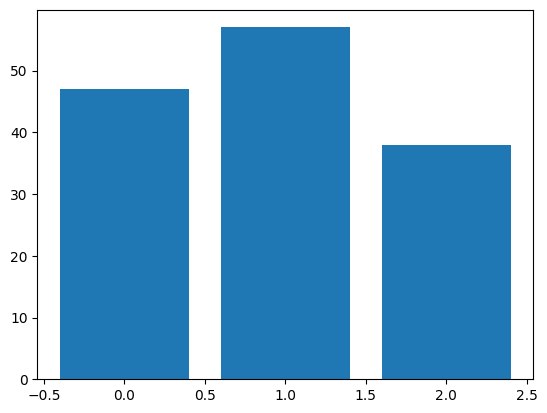

In [53]:
train_df= pd.read_csv("train.csv")
test_df= pd.read_csv("test.csv")

X_train= preprocess_data(train_df.drop(columns=['target']))
y_train= train_df['target']

X_test= preprocess_data(test_df)

plt.bar(np.unique_counts(y_train).values, np.unique_counts(y_train).counts)
plt.show()

In [54]:
from catboost import CatBoostClassifier

model= CatBoostClassifier(
    iterations= 3000,
    learning_rate= 0.03,
    depth= 6,
    auto_class_weights='Balanced',
    early_stopping_rounds=200,
    random_state= seed,
)

model.fit(X_train, y_train, verbose=200)

0:	learn: 1.0719669	total: 16.9ms	remaining: 50.6s
200:	learn: 0.0950349	total: 193ms	remaining: 2.69s
400:	learn: 0.0356465	total: 360ms	remaining: 2.33s
600:	learn: 0.0205023	total: 531ms	remaining: 2.12s
800:	learn: 0.0140834	total: 700ms	remaining: 1.92s
1000:	learn: 0.0105893	total: 867ms	remaining: 1.73s
1200:	learn: 0.0084849	total: 1.03s	remaining: 1.55s
1400:	learn: 0.0070391	total: 1.19s	remaining: 1.36s
1600:	learn: 0.0060310	total: 1.35s	remaining: 1.18s
1800:	learn: 0.0052562	total: 1.51s	remaining: 1.01s
2000:	learn: 0.0046770	total: 1.68s	remaining: 839ms
2200:	learn: 0.0042236	total: 1.84s	remaining: 669ms
2400:	learn: 0.0038424	total: 2.01s	remaining: 503ms
2600:	learn: 0.0035312	total: 2.18s	remaining: 335ms
2800:	learn: 0.0032499	total: 2.35s	remaining: 167ms
2999:	learn: 0.0030142	total: 2.51s	remaining: 0us


CatBoostClassifier(auto_class_weights='Balanced', depth=6, early_stopping_rounds=200, iterations=3000, learning_rate=0.03, random_state=42)

In [55]:
predictions= model.predict(X_test).reshape(1,-1)

answer=pd.DataFrame({
    'SampleID': test_df['SampleID'],
    'label': predictions[0]
})

answer.head()

,SampleID,label
0,11,0
1,135,2
2,29,0
3,122,1
4,63,1


In [56]:
answer.to_csv("submission.csv", index= False)